In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [107]:
#Random number generation for data generation
np.random.seed(42)

In [108]:
#no of houses
m = 100

#House size between 0 - 2
X = 2 * np.random.rand(m, 1)

#y = price of house
#h = theta0 + theta1 . X -> Model
#3 and 4 are random initiial number we have set
#rough price = 3 + 4 * size + some noise
y = 3 + 4 * X + np.random.rand(m, 1)


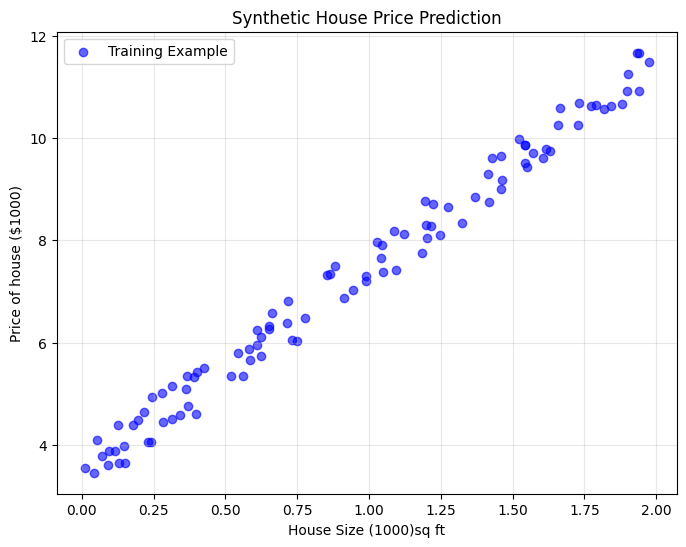

In [109]:
plt.figure(figsize=(8,6))
plt.scatter(X, y, color='blue', alpha=0.6, label='Training Example')
plt.xlabel('House Size (1000)sq ft')
plt.ylabel('Price of house ($1000)')
plt.title('Synthetic House Price Prediction')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Cost Function

In [110]:
def compute_cost(X, y, theta0, theta1):
    squared_errors = None
    sumed_sq_error = 0.0
    #no of total data
    m = len(X)
    for i in range(m):
        predictions = theta0 + (theta1 * X[i])
        errors = predictions - y[i]
        squared_errors = errors ** 2
        sumed_sq_error = squared_errors + sumed_sq_error
    cost = sumed_sq_error/(2*m)
    return cost
    

In [111]:
theta0 = 3
theta1 = 4
cost = compute_cost(X, y, theta0, theta1)
print(f"Current Cost: {cost}")

Current Cost: [0.16644574]


In [112]:
def graident_descent(X, y, theta0, theta1, alpha, no_iteration):
    cost_history = []
    m = X.shape[0]
    for i in range(no_iteration):
        summed_error_theta0 = 0
        summed_error_theta1 = 0
        for j in range(m):
            prediction = theta0 + (theta1 * X[j])
            error = prediction - y[j]
            summed_error_theta0 += error
            summed_error_theta1 += error * X[j]
            
        average_error_theta0 = summed_error_theta0 / m
        average_error_theta1 = summed_error_theta1 / m

        new_theta0 = theta0 - alpha * average_error_theta0
        new_theta1 = theta1 - alpha * average_error_theta1

        theta0 = new_theta0
        theta1 = new_theta1

        cost = compute_cost(X, y, theta0, theta1)
        cost_history.append(cost)
    #print(cost_history[0: 5])
    return theta0, theta1, cost_history


In [117]:
theta0 = 3
theta1 = 4
alpha = 0.1
no_iteration = 50
new_theta0, new_theta1, cost_history = graident_descent(X, y, theta0, theta1, alpha, no_iteration)
cost = compute_cost(X, y, new_theta0, new_theta1)
print(f"Initial Cost: {cost_history[0]}")
print(f"Current Cost: {cost}")


Initial Cost: [0.12501561]
Current Cost: [0.04488216]


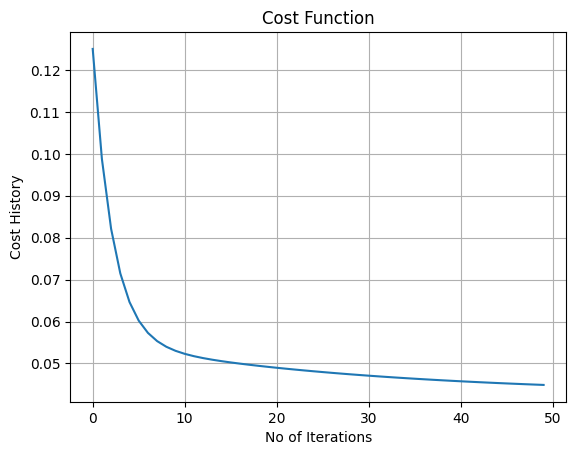

In [118]:
#Visualizing Gradient Descent
plt.plot(range(no_iteration), cost_history)
plt.xlabel("No of Iterations")
plt.ylabel("Cost History")
plt.title("Cost Function")
plt.grid(True)
plt.show()

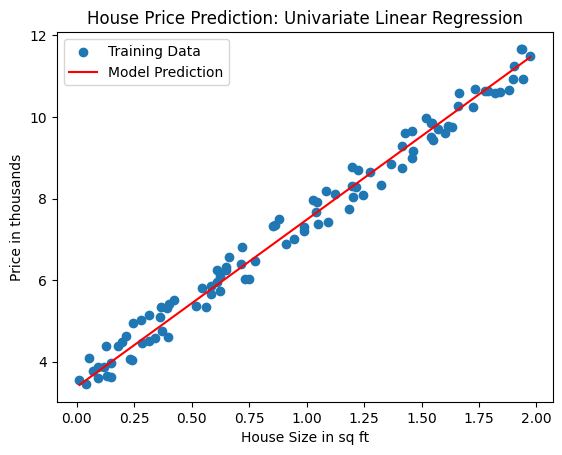

In [133]:
x_line = np.linspace(np.min(X), np.max(X), 50)
y_line = new_theta0 + new_theta1 * x_line
plt.scatter(X, y, label="Training Data")
plt.plot(x_line, y_line, color="red", label="Model Prediction")
plt.xlabel("House Size in sq ft")
plt.ylabel("Price in thousands")
plt.title("House Price Prediction: Univariate Linear Regression")
plt.legend()
plt.show()